loan approval - pca pipeline
----------------------------------------
original features: 8
features after pca: 8
variance kept: 100.0 %
----------------------------------------
without pca accuracy: 0.617
with pca accuracy:    0.617
----------------------------------------


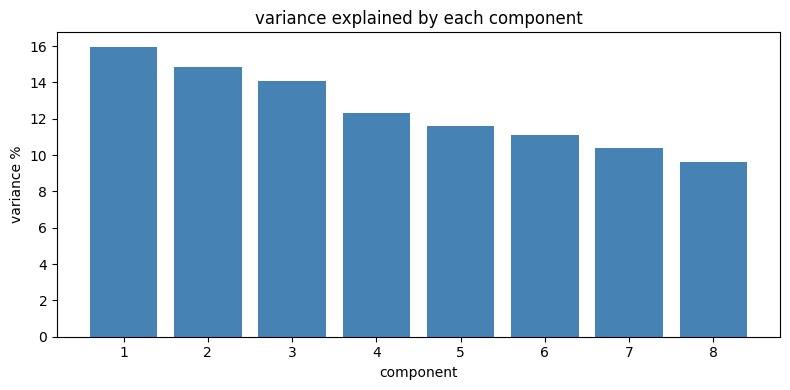

              precision    recall  f1-score   support

    rejected       0.56      0.21      0.30        24
    approved       0.63      0.89      0.74        36

    accuracy                           0.62        60
   macro avg       0.59      0.55      0.52        60
weighted avg       0.60      0.62      0.56        60



In [5]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 300

data = {
    "age":         np.random.randint(20, 60, n),
    "income":      np.random.randint(15000, 200000, n),
    "savings":     np.random.randint(0, 500000, n),
    "loans":       np.random.randint(0, 300000, n),
    "investments": np.random.randint(0, 400000, n),
    "expenses":    np.random.randint(5000, 80000, n),
    "credit":      np.random.randint(300, 900, n),
    "years_job":   np.random.randint(0, 20, n),
    "approved":    np.random.choice([0, 1], n, p=[0.4, 0.6])
}

df = pd.DataFrame(data)
x = df.drop("approved", axis=1)
y = df["approved"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

pipe1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipe2 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", LogisticRegression(max_iter=1000))
])

pipe1.fit(x_train, y_train)
pipe2.fit(x_train, y_train)

acc1 = round(accuracy_score(y_test, pipe1.predict(x_test)), 3)
acc2 = round(accuracy_score(y_test, pipe2.predict(x_test)), 3)

pca_step = pipe2.named_steps["pca"]

print("loan approval - pca pipeline")
print("-" * 40)
print("original features:", x.shape[1])
print("features after pca:", pca_step.n_components_)
print("variance kept:", round(sum(pca_step.explained_variance_ratio_)*100, 1), "%")
print("-" * 40)
print("without pca accuracy:", acc1)
print("with pca accuracy:   ", acc2)
print("-" * 40)

plt.figure(figsize=(8, 4))
plt.bar(range(1, pca_step.n_components_ + 1),
        pca_step.explained_variance_ratio_ * 100,
        color="steelblue")
plt.title("variance explained by each component")
plt.xlabel("component")
plt.ylabel("variance %")
plt.tight_layout()
plt.show()

print(classification_report(y_test, pipe2.predict(x_test),
      target_names=["rejected", "approved"]))